# X-Band Downlink Link Budget: 600 km SSO to Ground Station

Demonstration of the **missiontools** `Link` class for RF link budget analysis.

**Scenario**
- 600 km sun-synchronous orbit (LTAN 10:30), nadir-pointing
- X-band downlink at 8 250 MHz, 60 Mbps
- Ground station: Kiruna Space Centre, Sweden (67.9°N, 21.0°E)
- Modulation: QPSK, rate-3/4 turbo FEC — required Eb/N₀ = 7.0 dB
- Availability target: 99.9 % (ITU-R P.618 atmospheric attenuation applied)

In [ ]:
import warnings
import numpy as np
import matplotlib.pyplot as plt

from missiontools import Spacecraft, GroundStation, Link
from missiontools.comm import SymmetricAntenna
from missiontools.attitude import FixedAttitudeLaw, TrackAttitudeLaw
from missiontools.orbit.propagation import propagate_analytical
from missiontools.orbit.frames import geodetic_to_ecef, eci_to_ecef
import itur

## 1. Link Parameters

In [2]:
# Waveform / link parameters
FREQ_HZ      = 8.25e9    # centre frequency (Hz)  — ITU-R EO downlink band
DATA_RATE    = 60e6      # data rate (bit/s)
TX_POWER_W   = 8.0       # transmit power (W)  — solid-state PA, X-band
TX_POWER_DBW = 10 * np.log10(TX_POWER_W)
DISH_DIAM    = 3.7        # receive dish diameter (m) — Kiruna tracking station
DISH_EFF     = 0.6        # dish aperture efficiency
T_SYS_K     = 100.0      # system noise temperature (K) — subarctic + cryogenic LNA
REQ_EB_N0   = 7.0        # required Eb/N0 (dB)   — QPSK + rate-3/4 FEC, BER = 10⁻⁷
IMPL_LOSS   = 2.0        # implementation loss (dB)

print(f"Frequency      : {FREQ_HZ/1e9:.4f} GHz")
print(f"Data rate      : {DATA_RATE/1e6:.0f} Mbps  (10·log₁₀(Rb) = {10*np.log10(DATA_RATE):.1f} dB)")
print(f"TX power       : {TX_POWER_W:.0f} W  ({TX_POWER_DBW:.1f} dBW)")
print(f"RX dish        : {DISH_DIAM:.1f} m  (η = {DISH_EFF},  T_sys = {T_SYS_K:.0f} K)")
print(f"Required Eb/N0 : {REQ_EB_N0:.1f} dB")
print(f"Impl. loss     : {IMPL_LOSS:.1f} dB")

Frequency      : 8.2500 GHz
Data rate      : 60 Mbps  (10·log₁₀(Rb) = 77.8 dB)
TX power       : 8 W  (9.0 dBW)
RX dish        : 3.7 m  (η = 0.6,  T_sys = 100 K)
Required Eb/N0 : 7.0 dB
Impl. loss     : 2.0 dB


## 2. Spacecraft, Ground Station and Antennas

The transmit antenna is a shaped Earth-coverage beam mounted along the spacecraft
nadir axis (body-z).  The gain pattern is designed to remain high across the full
Earth disk visible from 600 km (half-angle ≈ 66°) and roll off sharply beyond it.

The receive antenna is a **3.7 m parabolic reflector** modelled with
`SymmetricAntenna.from_parabolic` (uniformly illuminated aperture, η = 0.6).
The dish tracks the spacecraft via `TrackAttitudeLaw`, so it is always on
boresight and receive gain equals the peak value at every timestep.  The system
G/T is derived from the dish peak gain and the assumed system noise temperature.

In [ ]:
EPOCH = np.datetime64('2025-06-21T00:00:00', 'us')  # June solstice

# Spacecraft
sc = Spacecraft.sunsync(altitude_km=600.0, node_solar_time='10:30', epoch=EPOCH)
sc.attitude_law = FixedAttitudeLaw.nadir()

# TX antenna — Earth coverage beam, nadir-mounted (body-z)
tx_angles = np.array([  0,  30,  55,  65,  70,  80,  90], dtype=float)  # off-boresight (°)
tx_gains  = np.array([ 12,  12,  11,   9,   4,  -3, -10], dtype=float)  # gain (dBi)
tx = SymmetricAntenna(tx_angles, tx_gains, body_vector=[0, 0, 1])
sc.add_antenna(tx)

# Ground station: Kiruna Space Centre, Sweden
gs = GroundStation(lat=67.86, lon=20.97, alt=390)

# RX: 3.7 m parabolic dish, tracking the spacecraft
rx = SymmetricAntenna.from_parabolic(DISH_DIAM, FREQ_HZ, eff=DISH_EFF,
                                      attitude_law=TrackAttitudeLaw(sc))
gs.add_antenna(rx)

# G/T derived from dish peak gain and system noise temperature
G_T_DB_K = rx.peak_gain_dbi - 10.0 * np.log10(T_SYS_K)

alt_km = (sc.a - 6_371_000) / 1e3
print(f"Orbit          : {alt_km:.0f} km SSO,  i = {np.degrees(sc.i):.2f}°,  LTAN 10:30")
print(f"Ground station : Kiruna  ({gs.lat}°N, {gs.lon}°E,  {gs.alt} m a.s.l.)")
print(f"TX antenna     : peak {tx.gains_dbi[0]:.0f} dBi,  body-z (nadir boresight)")
print(f"RX antenna     : {DISH_DIAM:.1f} m parabolic  (η = {DISH_EFF}),  "
      f"peak {rx.peak_gain_dbi:.1f} dBi,  tracking SC")
print(f"RX G/T         : {G_T_DB_K:.1f} dB/K  (T_sys = {T_SYS_K:.0f} K)")

# Link
link = Link(
    tx=tx, rx=rx,
    tx_power_dbw=TX_POWER_DBW,
    frequency_hz=FREQ_HZ,
    data_rate_bps=DATA_RATE,
    rx_gt_db_k=G_T_DB_K,
    required_eb_n0_db=REQ_EB_N0,
    implementation_loss_db=IMPL_LOSS,
    use_p618=True,
)

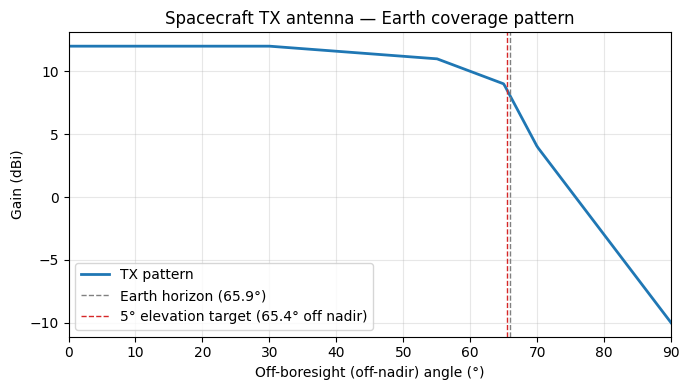

Gain at 5° elevation (65.4° off nadir): 8.6 dBi


In [4]:
# Earth disk half-angle from 600 km altitude
R_E = 6_371_000.0
H   = sc.a - R_E
disk_half_deg = np.degrees(np.arcsin(R_E / (sc.a)))  # nadir angle at horizon
el5_nadir     = np.degrees(np.arcsin(R_E * np.cos(np.radians(5)) / sc.a))  # nadir @ 5° el

angles_fine = np.linspace(0, 90, 400)
gains_fine  = np.interp(angles_fine, tx.angles_deg, tx.gains_dbi)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(angles_fine, gains_fine, linewidth=2, color='tab:blue', label='TX pattern')
ax.axvline(disk_half_deg, color='grey',    linestyle='--', linewidth=1.0,
           label=f'Earth horizon ({disk_half_deg:.1f}°)')
ax.axvline(el5_nadir,    color='tab:red', linestyle='--', linewidth=1.0,
           label=f'5° elevation target ({el5_nadir:.1f}° off nadir)')
ax.set_xlabel('Off-boresight (off-nadir) angle (°)')
ax.set_ylabel('Gain (dBi)')
ax.set_title('Spacecraft TX antenna — Earth coverage pattern')
ax.legend(loc='lower left')
ax.set_xlim(0, 90)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

g_at_5deg = float(np.interp(el5_nadir, tx.angles_deg, tx.gains_dbi))
print(f"Gain at 5° elevation ({el5_nadir:.1f}° off nadir): {g_at_5deg:.1f} dBi")

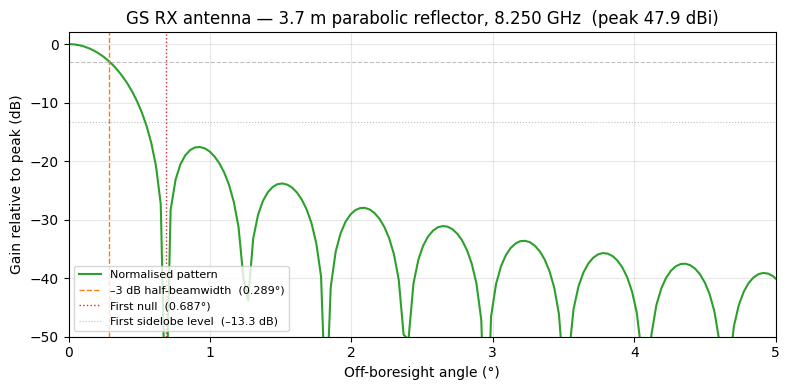

Peak gain      : 47.9 dBi
HPBW           : 0.579°
First null     : 0.687°
G/T            : 27.9 dB/K  (T_sys = 100 K)


In [5]:
_lam = 299_792_458.0 / FREQ_HZ

# –3 dB half-beamwidth: [2J₁(u)/u]² = 0.5 at u ≈ 1.616
hpbw_half_deg = np.degrees(np.arcsin(min(1.0, 1.616 * _lam / (np.pi * DISH_DIAM))))
# First null: J₁ = 0 at u = 3.8317 → sin(θ) = 1.22 λ/D
theta_null_deg = np.degrees(np.arcsin(min(1.0, 1.22 * _lam / DISH_DIAM)))

angles_rx_fine = np.linspace(0.0, 5.0, 3000)   # zoom to main lobe + first few sidelobes
gains_rx_fine  = np.interp(angles_rx_fine, rx.angles_deg, rx.gains_dbi)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(angles_rx_fine, gains_rx_fine - rx.peak_gain_dbi,
        linewidth=1.5, color='tab:green', label='Normalised pattern')
ax.axvline(hpbw_half_deg, color='tab:orange', linestyle='--', linewidth=1.0,
           label=f'–3 dB half-beamwidth  ({hpbw_half_deg:.3f}°)')
ax.axvline(theta_null_deg, color='tab:red', linestyle=':', linewidth=1.0,
           label=f'First null  ({theta_null_deg:.3f}°)')
ax.axhline(-3,    color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axhline(-13.3, color='grey', linestyle=':',  linewidth=0.8, alpha=0.5,
           label='First sidelobe level  (–13.3 dB)')
ax.set_xlabel('Off-boresight angle (°)')
ax.set_ylabel('Gain relative to peak (dB)')
ax.set_title(f'GS RX antenna — {DISH_DIAM:.1f} m parabolic reflector, '
             f'{FREQ_HZ/1e9:.3f} GHz  (peak {rx.peak_gain_dbi:.1f} dBi)')
ax.legend(fontsize=8, loc='lower left')
ax.set_xlim(0, 5)
ax.set_ylim(-50, 2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Peak gain      : {rx.peak_gain_dbi:.1f} dBi")
print(f"HPBW           : {2*hpbw_half_deg:.3f}°")
print(f"First null     : {theta_null_deg:.3f}°")
print(f"G/T            : {G_T_DB_K:.1f} dB/K  (T_sys = {T_SYS_K:.0f} K)")

## 3. Contact Windows

In [6]:
t_start = EPOCH
t_end   = EPOCH + np.timedelta64(1, 'D')
passes  = gs.access(sc, t_start, t_end, el_min=5.0, max_step=np.timedelta64(30, 's'))
print(f"Passes above 5° elevation in 24 h: {len(passes)}")

def _max_el(sc, gs, aos, los, npts=20):
    """Approximate peak elevation during a pass."""
    ts = aos + np.arange(npts) * ((los - aos) / (npts - 1))
    r_eci, _ = propagate_analytical(ts, **sc.keplerian_params, propagator_type=sc.propagator_type)
    r_ecef   = eci_to_ecef(r_eci, ts)
    r_gs     = geodetic_to_ecef(np.radians(gs.lat), np.radians(gs.lon), gs.alt)
    delta    = r_ecef - r_gs
    rng      = np.linalg.norm(delta, axis=1)
    lat_r, lon_r = np.radians(gs.lat), np.radians(gs.lon)
    up = np.array([np.cos(lat_r)*np.cos(lon_r), np.cos(lat_r)*np.sin(lon_r), np.sin(lat_r)])
    return float(np.degrees(np.arcsin(np.einsum('ij,j->i', delta, up) / rng)).max())

max_els = [_max_el(sc, gs, *p) for p in passes]
for i, ((a, l), me) in enumerate(zip(passes, max_els)):
    dur = (l - a) / np.timedelta64(1, 'm')
    mark = ' ◀ selected' if i == int(np.argmax(max_els)) else ''
    print(f"  Pass {i+1:>2}: AOS {str(a)[:19]}Z  dur {dur:4.1f} min  max el {me:4.1f}°{mark}")

best    = int(np.argmax(max_els))
aos, los = passes[best]

Passes above 5° elevation in 24 h: 11
  Pass  1: AOS 2025-06-21T01:12:56Z  dur 10.5 min  max el 76.7°
  Pass  2: AOS 2025-06-21T02:48:44Z  dur  9.8 min  max el 33.1°
  Pass  3: AOS 2025-06-21T04:24:16Z  dur  8.2 min  max el 16.8°
  Pass  4: AOS 2025-06-21T05:59:06Z  dur  7.2 min  max el 12.9°
  Pass  5: AOS 2025-06-21T07:33:00Z  dur  8.0 min  max el 16.2°
  Pass  6: AOS 2025-06-21T09:06:52Z  dur  9.7 min  max el 30.8°
  Pass  7: AOS 2025-06-21T10:41:48Z  dur 10.5 min  max el 79.5° ◀ selected
  Pass  8: AOS 2025-06-21T12:18:31Z  dur  9.5 min  max el 26.0°
  Pass  9: AOS 2025-06-21T13:58:09Z  dur  4.6 min  max el  7.4°
  Pass 10: AOS 2025-06-21T22:12:23Z  dur  5.5 min  max el  8.7°
  Pass 11: AOS 2025-06-21T23:47:22Z  dur  9.7 min  max el 29.2°


## 4. Link Margin During the Pass

Link margin is computed at 30-second intervals using `Link.link_margin()`, which
applies free-space path loss, the spacecraft transmit antenna pattern (gain vs.
nadir angle), and ITU-R P.618 atmospheric attenuation.  Points where the Earth
blocks the line of sight are returned as NaN.

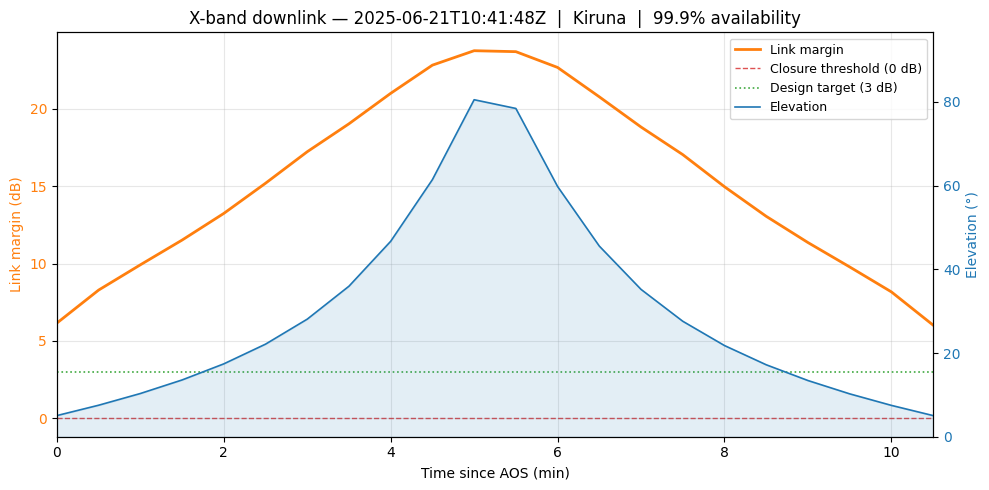

Pass statistics  (P.618 @ 99.9% availability, 8.25 GHz):
  Min margin : +6.0 dB  at el =  5.1°  (AOS/LOS)
  Max margin : +23.8 dB  at el = 80.5°  (max elevation)


In [7]:
STEP  = np.timedelta64(30, 's')
n_pts = int((los - aos) / STEP) + 1
t_pass = aos + np.arange(n_pts) * STEP

# Compute link margin (P.618 loop — takes a few seconds)
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    margin = link.link_margin(t_pass, availability_pct=99.9)

# Elevation angle at each timestep
r_sc_eci, _ = propagate_analytical(t_pass, **sc.keplerian_params, propagator_type=sc.propagator_type)
r_sc_ecef   = eci_to_ecef(r_sc_eci, t_pass)
r_gs_ecef   = geodetic_to_ecef(np.radians(gs.lat), np.radians(gs.lon), gs.alt)
delta_ecef  = r_sc_ecef - r_gs_ecef
rng_m       = np.linalg.norm(delta_ecef, axis=1)
lat_r, lon_r = np.radians(gs.lat), np.radians(gs.lon)
up_hat = np.array([np.cos(lat_r)*np.cos(lon_r), np.cos(lat_r)*np.sin(lon_r), np.sin(lat_r)])
el_deg = np.degrees(np.arcsin(np.einsum('ij,j->i', delta_ecef, up_hat) / rng_m))
t_min  = (t_pass - t_pass[0]).astype('int64') / 60e6   # minutes since AOS

ok = ~np.isnan(margin)  # unobstructed timesteps

# ── dual-axis plot ──
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax2.fill_between(t_min[ok], el_deg[ok], alpha=0.12, color='tab:blue')
ax2.plot(t_min[ok], el_deg[ok], color='tab:blue', linewidth=1.2, label='Elevation')
ax2.set_ylabel('Elevation (°)', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')
ax2.set_ylim(0, el_deg[ok].max() * 1.2)

ax1.plot(t_min[ok], margin[ok], color='tab:orange', linewidth=2.0, label='Link margin')
ax1.axhline(0, color='tab:red',   linestyle='--', linewidth=1.0, alpha=0.8, label='Closure threshold (0 dB)')
ax1.axhline(3, color='tab:green', linestyle=':',  linewidth=1.2, alpha=0.9, label='Design target (3 dB)')
ax1.set_xlabel('Time since AOS (min)')
ax1.set_ylabel('Link margin (dB)', color='tab:orange')
ax1.tick_params(axis='y', labelcolor='tab:orange')

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper right', fontsize=9)
ax1.set_title(f'X-band downlink — {str(aos)[:19]}Z  |  Kiruna  |  99.9% availability')
ax1.set_xlim(0, t_min[ok].max())
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Pass statistics  (P.618 @ 99.9% availability, 8.25 GHz):")
print(f"  Min margin : {margin[ok].min():+.1f} dB  at el = {el_deg[ok][np.nanargmin(margin[ok])]:4.1f}°  (AOS/LOS)")
print(f"  Max margin : {margin[ok].max():+.1f} dB  at el = {el_deg[ok][np.nanargmax(margin[ok])]:4.1f}°  (max elevation)")

## 5. Margin vs Elevation

Plotting margin against elevation angle shows how the link budget varies as the
satellite rises and sets.  The colour indicates time since AOS.

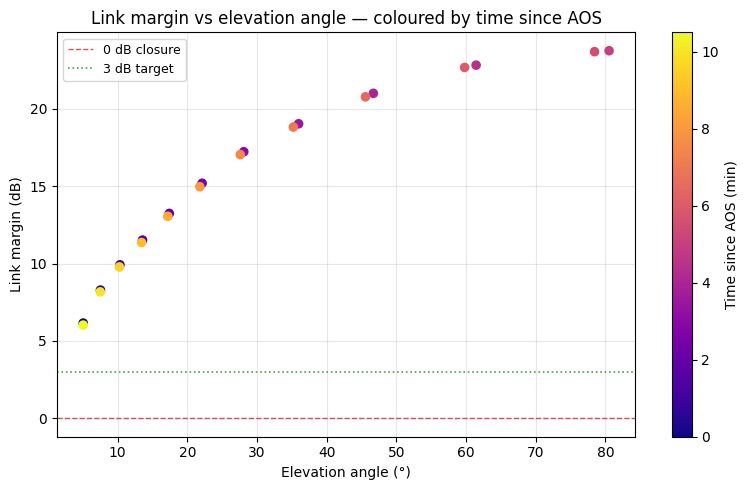

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
sc_pl = ax.scatter(el_deg[ok], margin[ok], c=t_min[ok], cmap='plasma', s=35, zorder=3)
ax.axhline(0, color='tab:red',   linestyle='--', linewidth=1.0, alpha=0.8, label='0 dB closure')
ax.axhline(3, color='tab:green', linestyle=':',  linewidth=1.2, alpha=0.9, label='3 dB target')
ax.set_xlabel('Elevation angle (°)')
ax.set_ylabel('Link margin (dB)')
ax.set_title('Link margin vs elevation angle — coloured by time since AOS')
cb = plt.colorbar(sc_pl, ax=ax)
cb.set_label('Time since AOS (min)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Link Budget Summary

The table below shows the complete link budget at a set of reference elevation
angles, computed analytically from geometry.  The off-nadir angle is derived
from the slant-range geometry; P.618 attenuation is evaluated with ITU-R P.618
at 99.9% availability.

In [9]:
_C   = 299_792_458.0
_R_E = 6_371_000.0
_H   = sc.a - _R_E
_K   = 10 * np.log10(1.380649e-23)   # Boltzmann constant in dBW/K/Hz ≈ −228.6

print("Link budget — 8.25 GHz  |  60 Mbps  |  99.9% availability  |  Kiruna")
print(f"TX: {TX_POWER_W:.0f} W ({TX_POWER_DBW:.1f} dBW)  |  "
      f"G/T: {G_T_DB_K:.1f} dB/K  |  Req Eb/N0: {REQ_EB_N0:.1f} dB  |  "
      f"Impl. loss: {IMPL_LOSS:.1f} dB")
print()
hdr = (f"  {'El':>3}  {'Off-nadir':>9}  {'G_tx':>5}  {'Range':>7}  "
       f"{'FSPL':>7}  {'EIRP':>7}  {'Eb/N0':>6}  {'P618':>5}  {'Margin':>7}")
print(hdr)
print('─' * len(hdr))

for el_v in [5, 10, 20, 30, 45, 60, 90]:
    el  = np.radians(el_v)
    rng = -_R_E*np.sin(el) + np.sqrt(_R_E**2*np.sin(el)**2 + _H**2 + 2*_R_E*_H)
    alpha  = np.degrees(np.arcsin(_R_E * np.cos(el) / (_R_E + _H)))
    g_tx   = float(np.interp(alpha, tx.angles_deg, tx.gains_dbi))
    fspl   = 20 * np.log10(4 * np.pi * rng * FREQ_HZ / _C)
    eirp   = TX_POWER_DBW + g_tx
    c_n0   = eirp - fspl + G_T_DB_K - _K
    eb_n0  = c_n0 - 10 * np.log10(DATA_RATE)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        a618 = itur.atmospheric_attenuation_slant_path(
                   gs.lat, gs.lon, FREQ_HZ / 1e9, el_v, 0.1, D=0)
    p618   = float(np.asarray(a618.value if hasattr(a618, 'value') else a618))
    mrg    = eb_n0 - REQ_EB_N0 - IMPL_LOSS - p618
    flag   = '  ◀ design point' if el_v == 5 else ''
    print(f"  {el_v:>3}°  {alpha:>8.1f}°  {g_tx:>5.1f}  {rng/1e3:>6.0f}km  "
          f"{fspl:>7.1f}  {eirp:>7.1f}  {eb_n0:>6.1f}  {p618:>5.2f}  {mrg:>+7.1f}{flag}")

print('─' * len(hdr))
print(f"  {'':>3}   {'(°)':>8}   {'(dBi)':>5}  {'':>7}  "
      f"{'(dB)':>7}  {'(dBW)':>7}  {'(dB)':>6}  {'(dB)':>5}  {'(dB)':>7}")

Link budget — 8.25 GHz  |  60 Mbps  |  99.9% availability  |  Kiruna
TX: 8 W (9.0 dBW)  |  G/T: 27.9 dB/K  |  Req Eb/N0: 7.0 dB  |  Impl. loss: 2.0 dB

   El  Off-nadir   G_tx    Range     FSPL     EIRP   Eb/N0   P618   Margin
──────────────────────────────────────────────────────────────────────────
    5°      65.4°    8.6    2345km    178.2     17.6    18.1   3.20     +5.9  ◀ design point
   10°      64.0°    9.2    1948km    176.6     18.2    20.4   1.59     +9.8
   20°      59.1°   10.2    1406km    173.7     19.2    24.2   0.80    +14.4
   30°      52.2°   11.1    1087km    171.5     20.1    27.3   0.54    +17.8
   45°      40.2°   11.6     824km    169.1     20.6    30.2   0.38    +20.8
   60°      27.2°   12.0     691km    167.6     21.0    32.2   0.31    +22.8
   90°       0.0°   12.0     607km    166.4     21.0    33.3   0.27    +24.0
──────────────────────────────────────────────────────────────────────────
             (°)   (dBi)              (dB)    (dBW)    (dB)   (dB)  